In [1]:
import pandas as pd
from ift6758.data import SeasonData
from ift6758.data.data_cleaning import clean_season_data, feature_engineering_1
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [2]:
# Make sure to run the get_train_and_test_sets_demo.ipynb notebook in the ift6758/notebooks folder to obtain the normal train and test sets before running this cell
dir = os.getcwd()
root = os.path.dirname(dir)
dataDir = os.path.join(root, "data", "NHLData")

training_set = pd.read_csv(os.path.join(dataDir, "training_set.csv"))

In [3]:
# Now, we can create a training dataframe with new features using our training set
new_features_train_df = feature_engineering_1(training_set)

new_features_train_df.head(10)

,distance_from_goal,angle_from_goal,is_goal,is_empty_net
0,13.000000,22.619865,0,0
1,13.341664,77.005383,0,0
2,76.157731,29.931512,0,0
3,57.974132,14.995079,0,0
4,61.717096,26.980231,0,0
5,58.523500,16.886791,0,0
6,19.026298,3.012788,1,0
7,56.850682,39.289407,0,0
8,58.821765,17.818889,0,0
9,58.523500,19.983107,0,0


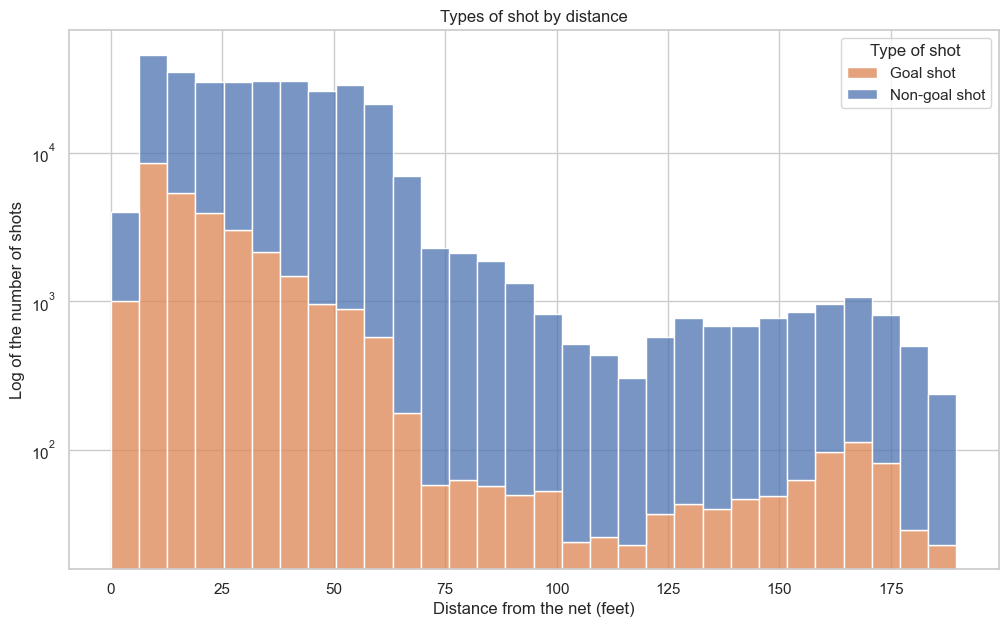

In [4]:
# Histogram of shots/goals by distance to the net

plt.figure(figsize=(12, 7))

sns.set_theme(style="whitegrid")
sns.histplot(data=new_features_train_df, x="distance_from_goal", hue="is_goal", bins=30, legend=True, multiple="stack")
plt.yscale("log")

plt.xlabel("Distance from the net (feet)")
plt.ylabel("Log of the number of shots")
plt.title("Types of shot by distance")
plt.legend(title="Type of shot", labels=["Goal shot", "Non-goal shot"])

plt.show()

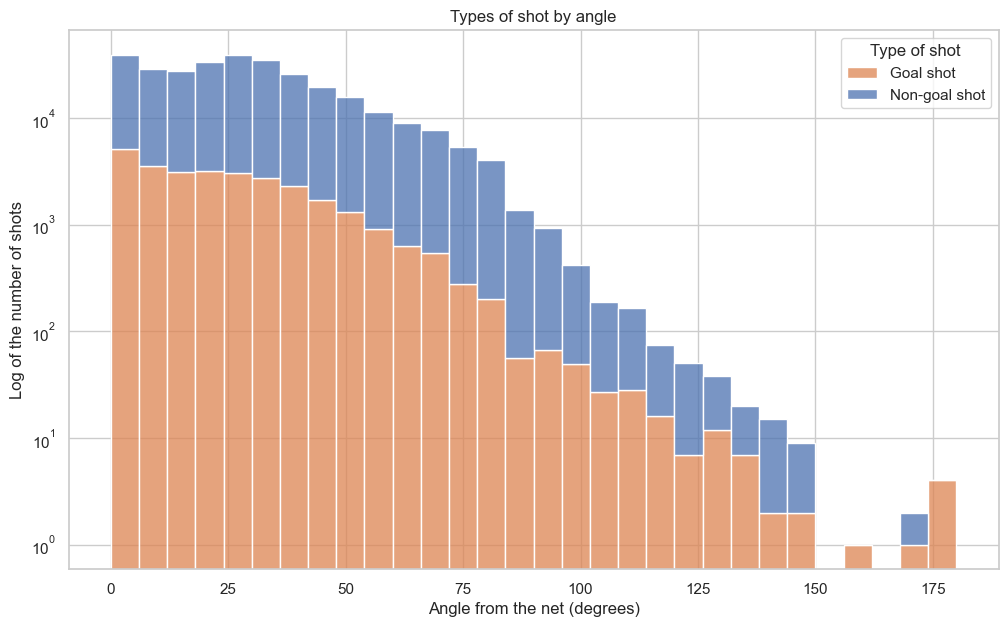

In [5]:
# Histogram of shots/goals by angle to the net

plt.figure(figsize=(12, 7))

sns.set_theme(style="whitegrid")
sns.histplot(data=new_features_train_df, x="angle_from_goal", hue="is_goal", bins=30, legend=True, multiple="stack")
plt.yscale("log")

plt.xlabel("Angle from the net (degrees)")
plt.ylabel("Log of the number of shots")
plt.title("Types of shot by angle")
plt.legend(title="Type of shot", labels=["Goal shot", "Non-goal shot"])
plt.show()

<Figure size 1500x800 with 0 Axes>

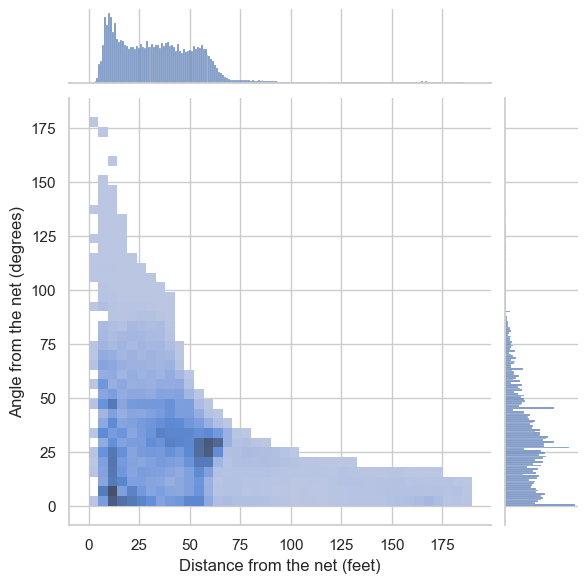

In [6]:
# Jointplot of distance from the net and angle

plt.figure(figsize=(15, 8))

sns.set_theme(style="whitegrid")
sns.jointplot(data=new_features_train_df, x="distance_from_goal", y="angle_from_goal", kind="hist", bins=40)

plt.xlabel("Distance from the net (feet)")
plt.ylabel("Angle from the net (degrees)")
plt.show()

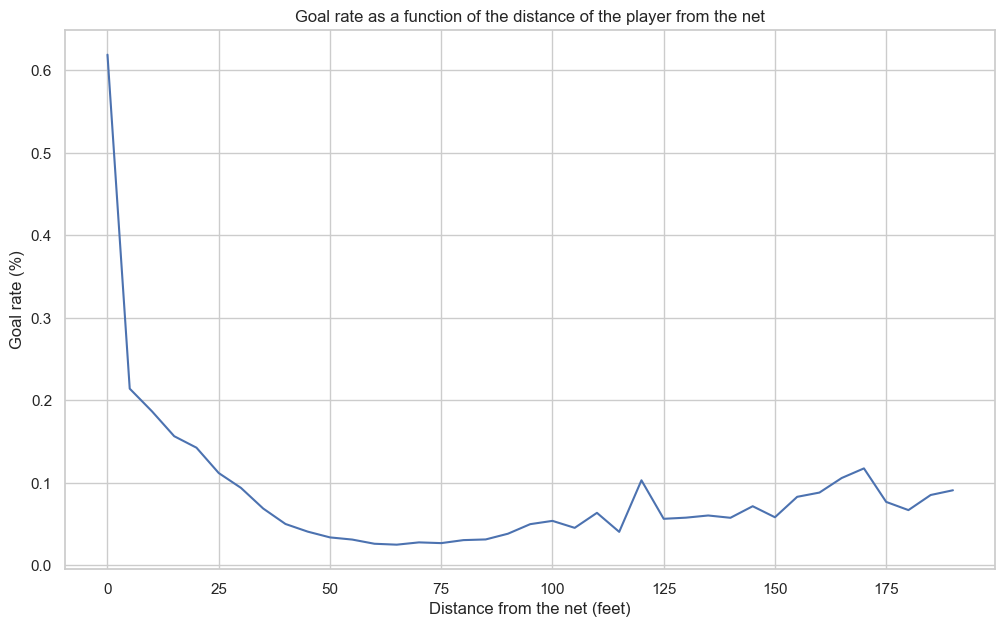

In [7]:
# Plot of goal rate by distance

goal_rate_distance_df = new_features_train_df.copy()
goal_rate_distance_df = goal_rate_distance_df[["distance_from_goal", "is_goal"]]

# To avoid a messy graph, we bin each distance value in intervals of 5 feet
goal_rate_distance_df["distance_from_goal"] = goal_rate_distance_df["distance_from_goal"].apply(lambda x: round(x/5) * 5 if not pd.isna(x) else np.nan)

goal_rate_distance_df = goal_rate_distance_df.groupby("distance_from_goal").value_counts()
goal_rate_distance_df = goal_rate_distance_df.unstack(level=1, fill_value=0)

goal_rate_distance_df["goal_rate"] = goal_rate_distance_df.apply(lambda x: x[1] / (x[0] + x[1]), axis=1)

# Now we can plot
plt.figure(figsize=(12, 7))
plt.plot(goal_rate_distance_df.index, goal_rate_distance_df["goal_rate"])

plt.xlabel("Distance from the net (feet)")
plt.ylabel("Goal rate (%)")
plt.title("Goal rate as a function of the distance of the player from the net")
plt.show()

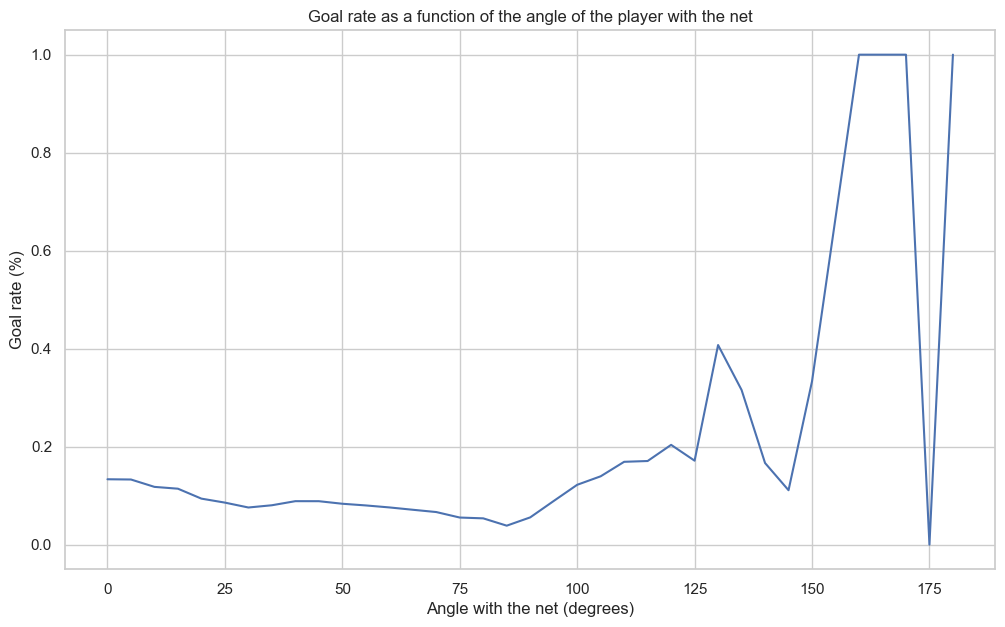

In [8]:
# Plot of goal rate by angle

goal_rate_angle_df = new_features_train_df.copy()
goal_rate_angle_df = goal_rate_angle_df[["angle_from_goal", "is_goal"]]

# To avoid a messy graph, we bin each angle value in intervals of 5 degrees
goal_rate_angle_df["angle_from_goal"] = goal_rate_angle_df["angle_from_goal"].apply(lambda x: round(x/5) * 5 if not pd.isna(x) else np.nan)

goal_rate_angle_df = goal_rate_angle_df.groupby("angle_from_goal").value_counts()
goal_rate_angle_df = goal_rate_angle_df.unstack(level=1, fill_value=0)

goal_rate_angle_df["goal_rate"] = goal_rate_angle_df.apply(lambda x: x[1] / (x[0] + x[1]), axis=1)

# Now we can plot
plt.figure(figsize=(12, 7))
plt.plot(goal_rate_angle_df.index, goal_rate_angle_df["goal_rate"])

plt.xlabel("Angle with the net (degrees)")
plt.ylabel("Goal rate (%)")
plt.title("Goal rate as a function of the angle of the player with the net")
plt.show()

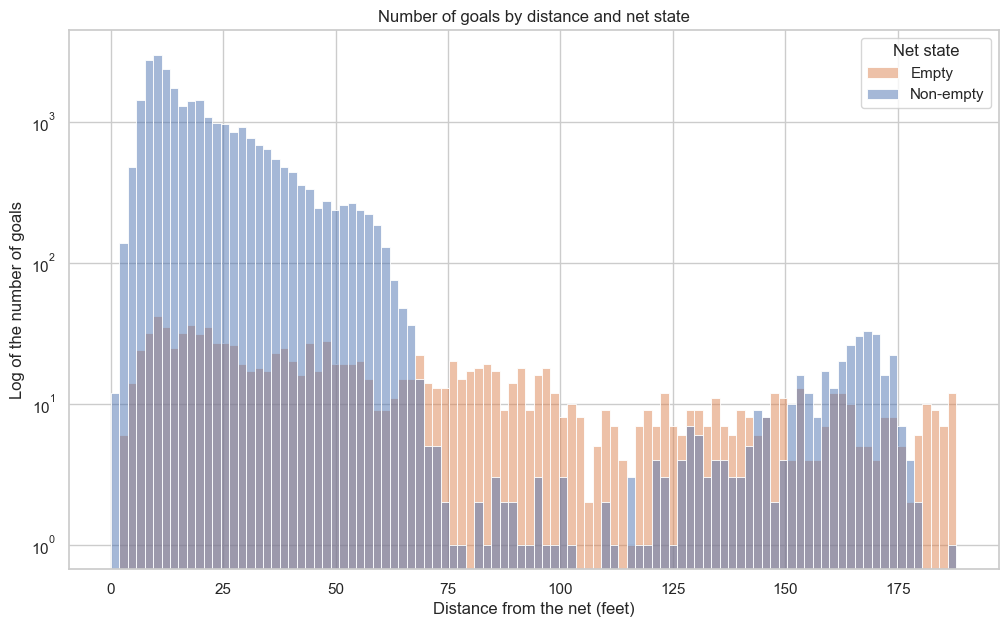

In [9]:
# Histogram of goals by distance, separated by the net being empty

goals_df = new_features_train_df[new_features_train_df["is_goal"] == 1]

plt.figure(figsize=(12, 7))

sns.set_theme(style="whitegrid")
sns.histplot(data=goals_df, x="distance_from_goal", hue="is_empty_net", bins=100, legend=True)
plt.yscale("log")

plt.xlabel("Distance from the net (feet)")
plt.ylabel("Log of the number of goals")
plt.title("Number of goals by distance and net state")
plt.legend(title="Net state", labels=["Empty", "Non-empty"])
plt.show()

In [10]:
# Extra experiment to spot anomalies
empty_net_goals_df = new_features_train_df[(new_features_train_df["distance_from_goal"] > 90) & (new_features_train_df["is_empty_net"] == 1) & (new_features_train_df["is_goal"] == 1)]
nonempty_net_goals_df = new_features_train_df[(new_features_train_df["distance_from_goal"] > 90) & (new_features_train_df["is_empty_net"] == 0) & (new_features_train_df["is_goal"] == 1)]

print(empty_net_goals_df)
print(nonempty_net_goals_df)

        distance_from_goal  angle_from_goal  is_goal  is_empty_net
187             124.197423        13.029195        1             1
361             117.902502        12.739647        1             1
1986             93.263069         4.304469        1             1
2167            173.118457         8.972627        1             1
2658            172.244013        12.745289        1             1
...                    ...              ...      ...           ...
303593          106.470653         5.389312        1             1
304015          136.616251        17.904448        1             1
304284          148.165448         2.707917        1             1
304530          101.237345        23.272904        1             1
305153          188.023935         0.914217        1             1

[429 rows x 4 columns]
        distance_from_goal  angle_from_goal  is_goal  is_empty_net
577              92.195445        12.528808        1             0
1806            123.794184         9.7

In [43]:
# Analyzing a random strange nonempty net goal
print(training_set.loc[300666])

## 26 (the Kings) starts by defending right, so in period 2 they would shoot right, meaning standardized coordinates work. 
## Dustin Brown indeed attacked on the right side, but his position on the ice was somehow in front of his own goal.
## This is because while the team did switch sides, the play-by-play data did not account for this in this match, there was an error

## In the next match, with ID 2019021002, they did switch sides

game_id                      2019021001
period                                2
period_time                       13:14
team                                 26
event_type                         Goal
x_coord                           -77.0
y_coord                             5.0
standardized_x_coord              -77.0
standardized_y_coord                5.0
shooter                  Player_8470606
goalie                   Goalie_8478406
shot_type                         wrist
empty_net                         False
strength                           Even
prev_play_event_type           giveaway
prev_play_period_time             13:10
prev_play_x_coord                 -65.0
prev_play_y_coord                 -41.0
season                             2019
Name: 300666, dtype: object


In [44]:
# Let's analyze another
print(training_set.loc[253627])

## 7 (the Buffalo Sabres) started by defending left, so in the 3rd period, they would be attacking right
## Jack Eichel attacked indeed from the left side into the right goal at a large distance, but from what we see in the replay, the goal was empty
## Here, the switching sides worked, but the goal was misclassified as being nonempty

game_id                      2019020256
period                                3
period_time                       19:22
team                                  7
event_type                         Goal
x_coord                           -83.0
y_coord                            -7.0
standardized_x_coord              -83.0
standardized_y_coord               -7.0
shooter                  Player_8478403
goalie                   Goalie_8470147
shot_type                         wrist
empty_net                         False
strength                           Even
prev_play_event_type       shot-on-goal
prev_play_period_time             19:20
prev_play_x_coord                 -38.0
prev_play_y_coord                  27.0
season                             2019
Name: 253627, dtype: object


In [45]:
# Let's analyze one final goal
print(training_set.loc[1806])

## 2 (the NY Islanders) began by defending the right net, so on the 3rd period they would be attacking left, so the standardization worked
## John Tavares indeed shot the goal, but he was positioned wrongly on the rink. According to the replay, he should have been right on the goal

game_id                      2016020030
period                                3
period_time                       07:59
team                                  2
event_type                         Goal
x_coord                            33.0
y_coord                            21.0
standardized_x_coord              -33.0
standardized_y_coord              -21.0
shooter                  Player_8475166
goalie                   Goalie_8476434
shot_type                         wrist
empty_net                         False
strength                           Even
prev_play_event_type       shot-on-goal
prev_play_period_time             07:59
prev_play_x_coord                 -74.0
prev_play_y_coord                   9.0
season                             2016
Name: 1806, dtype: object
